# Libraries

In [1]:
# !pip install -q gensim

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.nn import functional as F
from torch import optim
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from torch.utils.data import Dataset, DataLoader
import datasets
from huggingface_hub import login

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords

from gensim import downloader as api
from gensim.models import KeyedVectors
# from google.colab import drive

from tqdm.auto import tqdm, trange
import timeit
import gc
import re
import time

In [3]:
nltk.download("wordnet")
nltk.download("punkt_tab")
nltk.download("stopwords")
# login("hf_token")
# drive.mount("/content/drive")

# gc.collect()
# torch.cuda.empty_cache()

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
imdb = datasets.load_dataset("imdb")
train_set, test_set = imdb["train"], imdb["test"]

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [5]:
def dataset_tokenizer_01(text_corpus, tokenizer, lemmatizer, stopwords):
    output , labels = [], []
    stop_words = set(stopwords.words("english"))
    lemmatizer_instance = lemmatizer()
    for text in text_corpus:
        sent = []
        labels.append(text["label"])
        cleaned_regx = re.sub(r"[^\w\s]", "", text["text"])
        tokenized = tokenizer(cleaned_regx)

        for word in tokenized:
            if (word := word.lower()) not in stop_words:
                word = lemmatizer_instance.lemmatize(word)
                sent.append(word)

        output.append(sent)
    return output, labels

# start = time.time()
# preproccessed_text01, labels01 = dataset_tokenizer_01(train_set, word_tokenize, WordNetLemmatizer, stopwords)
# f"time : {time.time() - start}"
# out put time : 44.97586274147034

In [6]:

def dataset_tokenizer_02(text_corpus, tokenizer, lemmatizer, stopwords):
    output, labels = [], []

    for text in text_corpus:
        sentence = []
        labels.append(text["label"])
        tokenized = tokenizer(re.sub(r"[^\w\s]", "", text["text"]))

        for token in tokenized:
            token_lower = token.lower()

            if token_lower not in stopwords:
                lemm_token = lemmatizer.lemmatize(token_lower)
                sentence.append(np.array(lemm_token))

        output.append(np.array(sentence))
    return output, labels

start = time.time()
preproccessed_text02, labels02 = dataset_tokenizer_02(np.array(train_set), word_tokenize, WordNetLemmatizer(), set(stopwords.words("english")))
f"time : {time.time() - start}"
# out put time : 45.79623794555664

'time : 32.49094223976135'

In [7]:
_, c = np.unique(labels02, return_counts=True)
c

array([12500, 12500])

Ai generated

In [8]:
clean_re = re.compile(r"[^\w\s]")   # precompiled regex
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def dataset_tokenizer_03(text_corpus, tokenizer=word_tokenize):
    output, labels = [], []
    for text in text_corpus:
        labels.append(text["label"])
        cleaned = clean_re.sub("", text["text"])
        tokens = tokenizer(cleaned)

        sentence = [
            lemmatizer.lemmatize(tok.lower())
            for tok in tokens if tok.lower() not in stop_words
        ]
        output.append(sentence)

    return output, labels

# start = time.time()
# preproccessed_text03, labels03 = dataset_tokenizer_03(train_set)
# f"time : {time.time() - start}"
# out put time : 49.71739745140076


this is True

In [9]:
# preproccessed_text03 == preproccessed_text02 == preproccessed_text01


In [10]:
 # "word2vec-google-news-300"  ~ 3GB - 4GB
# word2vec = KeyedVectors.load("/content/drive/MyDrive/Models/w2v.model")
word2vec = api.load("word2vec-google-news-300");
 # 100MB - 200MB
# glove = api.load("glove-wiki-gigaword-300")

[==================================================] 100.0% 1662.8/1662.8MB downloaded


Embedding inside the dataset class is much more memory efficient this approach is not recommended

In [11]:
def embedding_w2v(sequence, embedding_model):
    #too slow!

    # output = []
    # for sent in sequence:
    #     embedded_sent = []

    #     for word in sent:
    #         if word in embedding_model:
    #             embedded_sent.append(embedding_model[word])

    #         else:
    #             embedded_sent.append(np.zeros(embedding_model.vector_size))

    #     output.append(embedded_sent)

    #dont turn this into tensor becuase its extrimly slow
    return [
        np.array([embedding_model[word] if word in embedding_model else np.zeros(embedding_model.vector_size) for word in sent])
        for sent in sequence]

start = time.time()
embedded_text01 = embedding_w2v(preproccessed_text02, word2vec)
f"time : {time.time() - start}"
#out put  without numpy time : 66.06606721878052
#out put with numpy time : 16.97495198249817
#torch was too slow and didnt run

'time : 12.07774567604065'

In [12]:
embedded_text01[0][0].shape

(300,)

In [13]:
val_text, val_labels = dataset_tokenizer_02(np.array(test_set), word_tokenize, WordNetLemmatizer(), set(stopwords.words("english")))
embedded_val_text = embedding_w2v(val_text, word2vec)

In [14]:
# after embedding
# del glove, preproccessed_text02
gc.collect()
torch.cuda.empty_cache()

# These takes your entire memory 🤯
don't do this

In [15]:
# lengths = [len(sent) for sent in embedded_text01]
# embedded_text01 = [torch.tensor(sent) for sent in embedded_text01]
# embedded_text01 = pad_sequence(embedded_text01, batch_first=True)
# lengths, indices = torch.sort(torch.tensor(lengths), descending = True)
# embedded_text01 = embedded_text01[indices]
# packed_seq = pack_padded_sequence(embedded_text01, lengths.cpu(), batch_first=True)

In [16]:
# lengths = [torch.tensor(len(sent)) for sent in embedded_text01]
# padded = pad_sequence(embedded_text01, batch_first=True)
# lengths_sorted, indices = torch.sort(lengths, decsending=True)
# sorted_padded = padded[indices]
# packed_padded_sequences = pack_padded_sequence(sorted_padded, lengths_sorted, batch_first=True, enforce_sorted=True)

use collate function

In [17]:
class DatasetWrapper(Dataset):
    def __init__(self, seq, labels):
        self.seq = seq
        self.labels = labels
    def __len__(self):
        return len(self.seq)
    def __getitem__(self, index):

        return  torch.tensor(self.seq[index], dtype=torch.float32), torch.tensor(self.labels[index], dtype=torch.float32)

def pad_and_pack(batch):
    sequences ,labels = zip(*batch)
    lengths = torch.tensor([len(seq) for seq in sequences]) # turn to tensor
    sorted_lengths, indices = torch.sort(lengths, descending=True)
    padded = pad_sequence(sequences, batch_first=True) # turn to tensor
    packed = pack_padded_sequence(padded[indices], sorted_lengths, batch_first=True, enforce_sorted=True)
    return packed, torch.tensor(labels)[indices]
    # note that you can turn enforce_sorted=True to False to avoid sorting manually


In [18]:
class MyLSTM(nn.Module):
    def __init__(self, vocab_size, hidden_dim, num_layers,drop_out, bidirectional):
        super().__init__()
        self.bidirectional = bidirectional
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        self.lstm1 = nn.LSTM(input_size=vocab_size, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True, dropout=drop_out, bidirectional=bidirectional)
        if bidirectional:
            self.fc1 = nn.Linear(self.hidden_dim * 2, 64, False)
        else:
            self.fc1 = nn.Linear(self.hidden_dim, 64, False)
        self.batchnorm1 = nn.BatchNorm1d(64)
        self.prelu = nn.PReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, 1)
    def forward(self, packed_input):
        packed_out , (h_n, c_n) = self.lstm1(packed_input) # h_n = (D*L, B, H)
        if self.bidirectional:
            view_h_n = h_n.view(self.num_layers, 2, h_n.size(1), self.hidden_dim).mean(0)
            lstm_out = torch.cat([view_h_n[0], view_h_n[1]], dim=1) # (B, 2*H)
        else:
            lstm_out = h_n.view(self.num_layers, h_n.size(1), self.hidden_dim)[-1].squeeze(0) #(B, H)
        return self.fc2(self.dropout(self.prelu(self.batchnorm1(self.fc1(lstm_out))))).squeeze()


In [19]:

def train_test_lstm_model(model, optimizer, criterion, train_set, val_set, device, n_epoch):
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=1)
    model = model.to(device)
    train_loss, train_accuracy, val_loss, val_accuracy = [], [], [], []
    for epoch in trange(n_epoch, leave=True):
        running_train_loss, running_val_loss, running_true_train, running_true_val = 0.0, 0.0, 0, 0
        total_number_train = 0
        total_number_val = 0
        model.train()
        for x_train, y_train in tqdm(train_set, leave=False):

            x_train, y_train = x_train.to(device), y_train.to(device)
            train_preds = model(x_train)
            optimizer.zero_grad()
            loss = criterion(train_preds, y_train)
            loss.backward()
            optimizer.step()
            total_number_train += y_train.size(0)
            train_pred_labels = (train_preds > 0).long()
            running_true_train += (train_pred_labels == y_train).sum().item()
            running_train_loss += loss.item() * y_train.size(0)

        model.eval()
        with torch.inference_mode():
            for x_val, y_val in tqdm(val_set, leave=False):

                x_val, y_val = x_val.to(device), y_val.to(device)
                val_preds = model(x_val)
                loss = criterion(val_preds, y_val)
                val_pred_labels = (val_preds > 0).long()
                running_true_val += (val_pred_labels == y_val).sum().item()
                total_number_val += y_val.size(0)
                running_val_loss += loss.item() * y_val.size(0)


        train_loss_epoch = running_train_loss / total_number_train
        train_acc_epoch  = running_true_train / total_number_train
        val_loss_epoch   = running_val_loss / total_number_val
        val_acc_epoch    = running_true_val / total_number_val

        train_loss.append(train_loss_epoch)
        train_accuracy.append(train_acc_epoch)
        val_loss.append(val_loss_epoch)
        val_accuracy.append(val_acc_epoch)

        scheduler.step(val_loss_epoch)

        print(
            f"Epoch {epoch+1:03d} | "
            f"Train Loss: {train_loss_epoch:.4f}, Acc: {train_acc_epoch:.4f} | "
            f"Val Loss: {val_loss_epoch:.4f}, Acc: {val_acc_epoch:.4f}"
        )


    return model, train_loss, train_accuracy, val_loss, val_accuracy

In [20]:
Batch_size = 16
val_dataset = DatasetWrapper(embedded_val_text, val_labels)
val_loader = DataLoader(val_dataset, Batch_size, shuffle=True, collate_fn=pad_and_pack)
dataset_train = DatasetWrapper(embedded_text01, labels02)
train_loader = DataLoader(dataset_train, Batch_size, shuffle=True, collate_fn=pad_and_pack)


In [21]:
model_01 = MyLSTM(300, 128, 3, 0.1, True)
model_01 = torch.compile(model_01)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model_01.parameters(), lr = 0.001, amsgrad=True, weight_decay=1e-4)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, train_loss, train_accuracy, val_loss, val_accuracy = train_test_lstm_model(model_01, optimizer, criterion, train_loader, val_loader, device, 10)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1563 [00:00<?, ?it/s]

  0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 001 | Train Loss: 0.4555, Acc: 0.7898 | Val Loss: 0.3684, Acc: 0.8323


  0%|          | 0/1563 [00:00<?, ?it/s]

...

  0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 009 | Train Loss: 0.1788, Acc: 0.9325 | Val Loss: 0.2835, Acc: 0.8914


  0%|          | 0/1563 [00:00<?, ?it/s]

  0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 010 | Train Loss: 0.1736, Acc: 0.9347 | Val Loss: 0.2816, Acc: 0.8920


In [22]:
# model_01 = model_01.to(device)
# labels = []
# for x, y in tqdm(train_loader):
#     print(y)
#     break
#     labels.extend(y)
# ys, counts = np.unique(labels, return_counts=True)
# counts

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

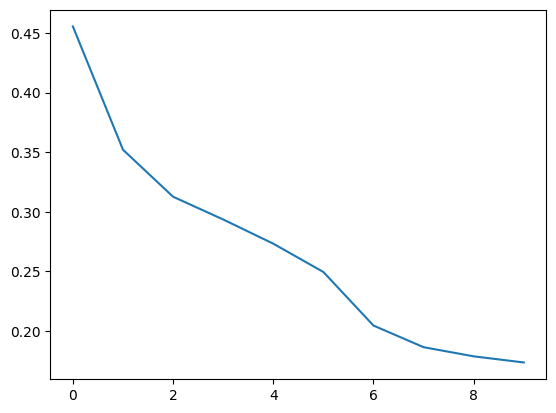

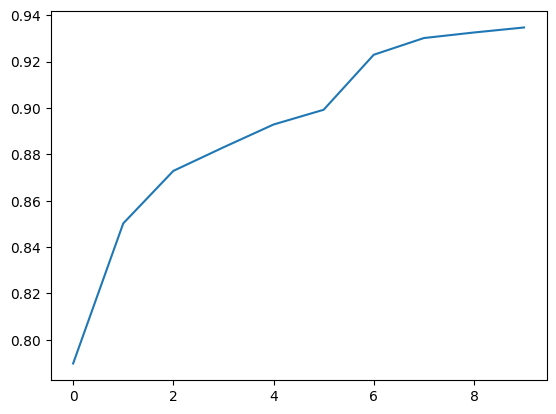

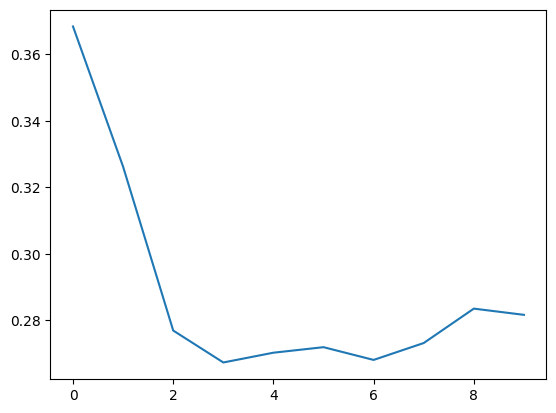

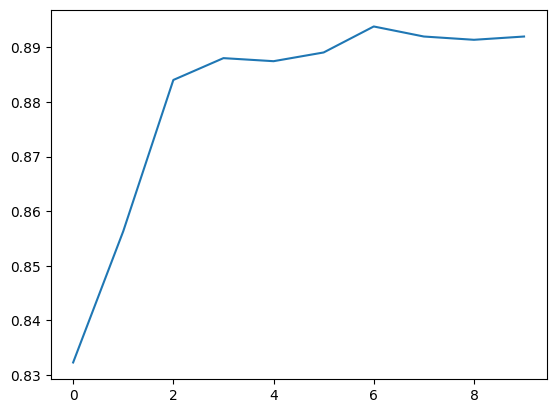

In [23]:
def visualize(train_loss, train_accuracy, val_loss, val_accuracy):
    plt.figure()
    sns.lineplot(train_loss)
    plt.figure()

    sns.lineplot(train_accuracy)
    plt.figure()

    sns.lineplot(val_loss)
    plt.figure()

    sns.lineplot(val_accuracy)
visualize(train_loss, train_accuracy, val_loss, val_accuracy)